
DESAFIO DE FECHAMENTO — SD-WAN ZERO-TRUST
Origem: 0
Destino: 11
Melhor rota encontrada: [0, 11]
Latência total: 18.00 ms
Perda de pacotes total: 4.88 %
Penalidade de segurança: 0.00
Fitness final: 66.80
Tempo de execução: 438.87 ms

REPUTAÇÃO DOS NÓS DA ROTA:
Nó 0: Reputação = 92.52 → CONFIÁVEL
Nó 11: Reputação = 66.30 → CONFIÁVEL


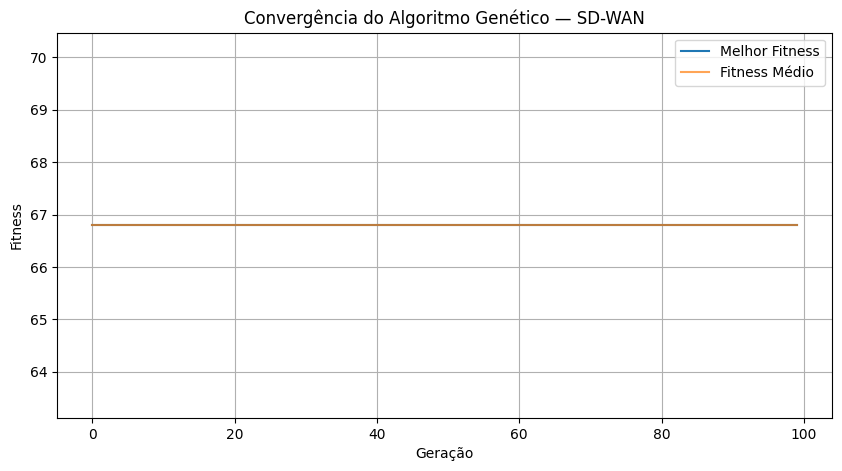

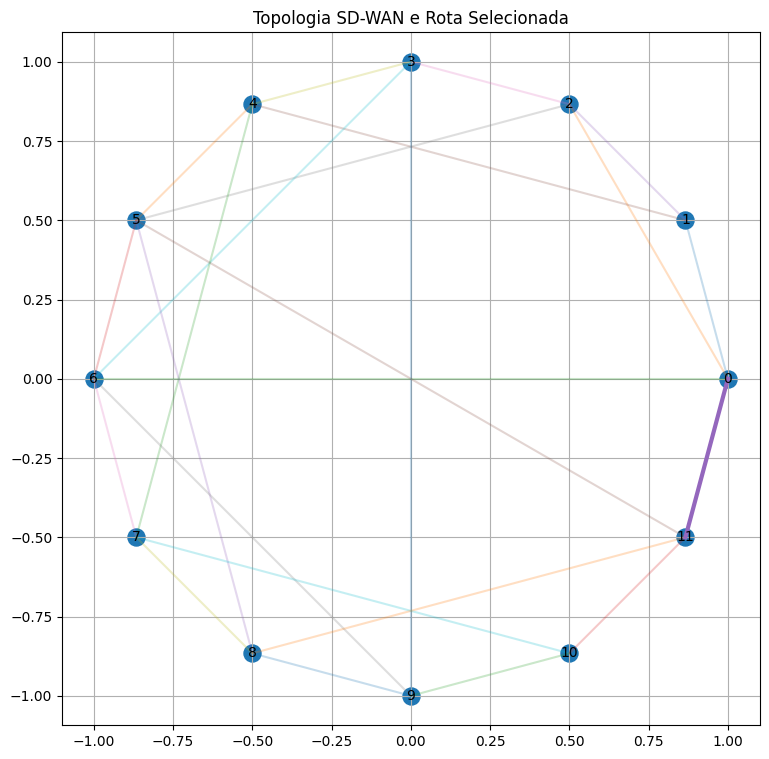

In [1]:
# ============================================================
# DESAFIO DE FECHAMENTO DA AC-1
# MOTOR DE DECISIONING SD-WAN ZERO-TRUST
#
# Relatório técnico:
# O algoritmo genético é utilizado para selecionar uma rota
# entre o nó de origem 0 e o nó de destino 11.
#
# A função de fitness considera três fatores:
# 1. Latência total da rota;
# 2. Perda de pacotes acumulada;
# 3. Penalidade de segurança de 5000 caso a rota passe
#    por qualquer nó cuja reputação seja inferior a 50.
#
# A penalidade de segurança faz com que rotas que utilizem
# nós considerados não confiáveis sejam desfavorecidas,
# mesmo que apresentem menor latência ou menor perda.
#
# A rota selecionada representa um compromisso entre desempenho
# e segurança, priorizando caminhos que evitem nós de baixa
# reputação quando houver alternativas viáveis.
# ============================================================


import numpy as np
import random
import time
import matplotlib.pyplot as plt


# ============================================================
# 1. CONFIGURAÇÕES
# ============================================================

np.random.seed(2026)
random.seed(2026)

NUM_NOS = 12

ORIGEM = 0
DESTINO = 11

TAMANHO_POPULACAO = 60
NUM_GERACOES = 100

TAXA_MUTACAO = 0.10

# Pesos da função de fitness
W1 = 1.0
W2 = 10.0

PENALIDADE_SEGURANCA = 5000.0

REPUTACAO_MINIMA = 50.0


# ============================================================
# 2. MATRIZES E ATRIBUTOS DA REDE
# ============================================================

# Matriz de adjacência.
# 1 = enlace existente
# 0 = ausência de enlace
#
# A matriz é construída de forma que todos os nós tenham
# conectividade suficiente para permitir a busca de rotas.

matriz_adjacencia = np.zeros(
    (NUM_NOS, NUM_NOS),
    dtype=int
)


# Criamos uma topologia em formato de anel
# para garantir conectividade entre os 12 roteadores.

for i in range(NUM_NOS):

    proximo = (i + 1) % NUM_NOS

    matriz_adjacencia[i, proximo] = 1
    matriz_adjacencia[proximo, i] = 1


# Adicionamos alguns enlaces extras para criar
# alternativas de rota.

enlaces_extras = [
    (0, 2),
    (1, 4),
    (2, 5),
    (3, 6),
    (4, 7),
    (5, 8),
    (6, 9),
    (7, 10),
    (8, 11),
    (0, 6),
    (3, 9),
    (5, 11)
]


for origem, destino in enlaces_extras:

    matriz_adjacencia[
        origem,
        destino
    ] = 1

    matriz_adjacencia[
        destino,
        origem
    ] = 1


# ============================================================
# 3. LATÊNCIA DOS ENLACES
# ============================================================

matriz_latencia = np.zeros(
    (NUM_NOS, NUM_NOS)
)


for i in range(NUM_NOS):

    for j in range(NUM_NOS):

        if matriz_adjacencia[i, j] == 1:

            matriz_latencia[i, j] = np.random.uniform(
                10,
                100
            )


# ============================================================
# 4. PERDA DE PACOTES
# ============================================================

matriz_perda = np.zeros(
    (NUM_NOS, NUM_NOS)
)


for i in range(NUM_NOS):

    for j in range(NUM_NOS):

        if matriz_adjacencia[i, j] == 1:

            matriz_perda[i, j] = np.random.uniform(
                0,
                5
            )


# ============================================================
# 5. REPUTAÇÃO DE SEGURANÇA DOS NÓS
# ============================================================

reputacao = np.random.uniform(
    0,
    100,
    NUM_NOS
)


# ============================================================
# 6. FUNÇÃO PARA VERIFICAR VIZINHOS
# ============================================================

def obter_vizinhos(no):

    return np.where(
        matriz_adjacencia[no] == 1
    )[0]


# ============================================================
# 7. GERAÇÃO DE UMA ROTA VÁLIDA
# ============================================================

def gerar_rota():

    rota = [ORIGEM]

    visitados = {ORIGEM}

    no_atual = ORIGEM

    max_passos = NUM_NOS * 2

    for _ in range(max_passos):

        if no_atual == DESTINO:
            break

        vizinhos = [
            int(v)
            for v in obter_vizinhos(no_atual)
            if int(v) not in visitados
        ]

        # Se não houver vizinhos não visitados,
        # tenta voltar ao início da construção.
        if not vizinhos:

            return None

        # Dá preferência ao destino quando ele está disponível.
        if DESTINO in vizinhos:

            proximo = DESTINO

        else:

            proximo = random.choice(
                vizinhos
            )

        rota.append(proximo)

        visitados.add(proximo)

        no_atual = proximo

        if no_atual == DESTINO:
            break

    if rota[-1] != DESTINO:

        return None

    return rota


# ============================================================
# 8. CRIAÇÃO DA POPULAÇÃO INICIAL
# ============================================================

def criar_populacao():

    populacao = []

    tentativas = 0

    while len(populacao) < TAMANHO_POPULACAO:

        rota = gerar_rota()

        if rota is not None:

            populacao.append(
                rota
            )

        tentativas += 1

        if tentativas > 10000:

            raise RuntimeError(
                "Não foi possível criar a população inicial."
            )

    return populacao


# ============================================================
# 9. CÁLCULO DA LATÊNCIA TOTAL
# ============================================================

def calcular_latencia_total(rota):

    total = 0.0

    for i in range(len(rota) - 1):

        origem = rota[i]

        destino = rota[i + 1]

        total += matriz_latencia[
            origem,
            destino
        ]

    return total


# ============================================================
# 10. CÁLCULO DA PERDA TOTAL
# ============================================================

def calcular_perda_total(rota):

    total = 0.0

    for i in range(len(rota) - 1):

        origem = rota[i]

        destino = rota[i + 1]

        total += matriz_perda[
            origem,
            destino
        ]

    return total


# ============================================================
# 11. PENALIDADE DE SEGURANÇA
# ============================================================

def calcular_penalidade_seguranca(rota):

    for no in rota:

        if reputacao[no] < REPUTACAO_MINIMA:

            return PENALIDADE_SEGURANCA

    return 0.0


# ============================================================
# 12. FUNÇÃO DE FITNESS
# ============================================================

def calcular_fitness(rota):

    latencia = calcular_latencia_total(
        rota
    )

    perda = calcular_perda_total(
        rota
    )

    penalidade = calcular_penalidade_seguranca(
        rota
    )

    fitness = (
        W1 * latencia
        +
        W2 * perda
        +
        penalidade
    )

    return fitness


# ============================================================
# 13. SELEÇÃO POR TORNEIO
# ============================================================

def selecao_torneio(
    populacao,
    fitnesses,
    tamanho_torneio=3
):

    indices = np.random.choice(
        len(populacao),
        tamanho_torneio,
        replace=False
    )

    melhor_indice = min(
        indices,
        key=lambda i: fitnesses[i]
    )

    return populacao[
        melhor_indice
    ].copy()


# ============================================================
# 14. CROSSOVER DE ROTAS
# ============================================================

def crossover(pai1, pai2):

    # Como as rotas podem ter tamanhos diferentes,
    # utilizamos uma combinação baseada nos nós comuns.

    conjunto_pai1 = set(pai1)

    conjunto_pai2 = set(pai2)

    comuns = [
        no for no in pai1
        if no in conjunto_pai2
    ]

    # Se não houver nós suficientes em comum,
    # retorna um dos pais.

    if len(comuns) < 2:

        return pai1.copy()

    ponto = random.randint(
        1,
        len(comuns) - 1
    )

    parte1 = comuns[:ponto]

    parte2 = [
        no for no in pai2
        if no not in parte1
    ]

    candidato = parte1 + parte2

    # Garante origem no início
    if ORIGEM in candidato:

        candidato.remove(
            ORIGEM
        )

    candidato.insert(
        0,
        ORIGEM
    )

    # Garante destino no final
    if DESTINO in candidato:

        candidato.remove(
            DESTINO
        )

    candidato.append(
        DESTINO
    )

    # Verifica se a rota é válida
    for i in range(
        len(candidato) - 1
    ):

        if matriz_adjacencia[
            candidato[i],
            candidato[i + 1]
        ] == 0:

            return pai1.copy()

    return candidato


# ============================================================
# 15. MUTAÇÃO
# ============================================================

def mutacao(rota):

    nova_rota = rota.copy()

    if random.random() >= TAXA_MUTACAO:

        return nova_rota

    if len(nova_rota) <= 2:

        return nova_rota

    posicao = random.randint(
        1,
        len(nova_rota) - 2
    )

    no_atual = nova_rota[
        posicao - 1
    ]

    vizinhos = [
        int(v)
        for v in obter_vizinhos(
            no_atual
        )
        if int(v) not in nova_rota
        and int(v) != DESTINO
    ]

    if not vizinhos:

        return nova_rota

    novo_no = random.choice(
        vizinhos
    )

    nova_rota[
        posicao
    ] = novo_no

    # Remove possíveis duplicações
    resultado = [ORIGEM]

    for no in nova_rota[1:-1]:

        if no not in resultado:

            resultado.append(no)

    resultado.append(
        DESTINO
    )

    # Verifica se todos os enlaces são válidos
    for i in range(
        len(resultado) - 1
    ):

        if matriz_adjacencia[
            resultado[i],
            resultado[i + 1]
        ] == 0:

            return rota.copy()

    return resultado


# ============================================================
# 16. EXECUÇÃO DO ALGORITMO GENÉTICO
# ============================================================

inicio = time.time()

populacao = criar_populacao()

melhor_rota_global = None

melhor_fitness_global = np.inf

historico_melhor = []

historico_medio = []


for geracao in range(
    NUM_GERACOES
):

    fitnesses = [
        calcular_fitness(
            rota
        )
        for rota in populacao
    ]


    # Melhor indivíduo da geração
    indice_melhor = np.argmin(
        fitnesses
    )

    melhor_rota_geracao = (
        populacao[
            indice_melhor
        ]
    )

    melhor_fitness_geracao = (
        fitnesses[
            indice_melhor
        ]
    )


    # Atualiza melhor solução global
    if (
        melhor_fitness_geracao
        <
        melhor_fitness_global
    ):

        melhor_fitness_global = (
            melhor_fitness_geracao
        )

        melhor_rota_global = (
            melhor_rota_geracao.copy()
        )


    historico_melhor.append(
        melhor_fitness_global
    )

    historico_medio.append(
        np.mean(fitnesses)
    )


    # Elitismo
    nova_populacao = [
        melhor_rota_global.copy()
    ]


    # Reprodução
    while len(
        nova_populacao
    ) < TAMANHO_POPULACAO:

        pai1 = selecao_torneio(
            populacao,
            fitnesses
        )

        pai2 = selecao_torneio(
            populacao,
            fitnesses
        )

        filho = crossover(
            pai1,
            pai2
        )

        filho = mutacao(
            filho
        )

        nova_populacao.append(
            filho
        )


    populacao = nova_populacao


fim = time.time()


# ============================================================
# 17. RESULTADOS FINAIS
# ============================================================

latencia_final = calcular_latencia_total(
    melhor_rota_global
)

perda_final = calcular_perda_total(
    melhor_rota_global
)

penalidade_final = calcular_penalidade_seguranca(
    melhor_rota_global
)

fitness_final = calcular_fitness(
    melhor_rota_global
)

tempo_execucao = (
    fim - inicio
) * 1000


print("\n" + "=" * 65)
print("DESAFIO DE FECHAMENTO — SD-WAN ZERO-TRUST")
print("=" * 65)

print(
    f"Origem: {ORIGEM}"
)

print(
    f"Destino: {DESTINO}"
)

print(
    f"Melhor rota encontrada: "
    f"{melhor_rota_global}"
)

print(
    f"Latência total: "
    f"{latencia_final:.2f} ms"
)

print(
    f"Perda de pacotes total: "
    f"{perda_final:.2f} %"
)

print(
    f"Penalidade de segurança: "
    f"{penalidade_final:.2f}"
)

print(
    f"Fitness final: "
    f"{fitness_final:.2f}"
)

print(
    f"Tempo de execução: "
    f"{tempo_execucao:.2f} ms"
)

print("=" * 65)


# ============================================================
# 18. REPUTAÇÃO DOS NÓS DA ROTA
# ============================================================

print("\nREPUTAÇÃO DOS NÓS DA ROTA:")

for no in melhor_rota_global:

    status = (
        "NÃO CONFIÁVEL"
        if reputacao[no] < REPUTACAO_MINIMA
        else "CONFIÁVEL"
    )

    print(
        f"Nó {no}: "
        f"Reputação = {reputacao[no]:.2f} "
        f"→ {status}"
    )


# ============================================================
# 19. GRÁFICO DE CONVERGÊNCIA
# ============================================================

plt.figure(
    figsize=(10, 5)
)

plt.plot(
    historico_melhor,
    label="Melhor Fitness"
)

plt.plot(
    historico_medio,
    label="Fitness Médio",
    alpha=0.7
)

plt.xlabel(
    "Geração"
)

plt.ylabel(
    "Fitness"
)

plt.title(
    "Convergência do Algoritmo Genético — SD-WAN"
)

plt.grid(True)

plt.legend()

plt.show()


# ============================================================
# 20. VISUALIZAÇÃO DA TOPOLOGIA
# ============================================================

# Posições circulares para os roteadores

angulos = np.linspace(
    0,
    2 * np.pi,
    NUM_NOS,
    endpoint=False
)

posicoes = np.column_stack(
    (
        np.cos(angulos),
        np.sin(angulos)
    )
)


plt.figure(
    figsize=(9, 9)
)


# Desenha todos os enlaces
for i in range(NUM_NOS):

    for j in range(
        i + 1,
        NUM_NOS
    ):

        if matriz_adjacencia[
            i,
            j
        ] == 1:

            plt.plot(
                [
                    posicoes[i, 0],
                    posicoes[j, 0]
                ],
                [
                    posicoes[i, 1],
                    posicoes[j, 1]
                ],
                alpha=0.25
            )


# Destaca a rota encontrada
for i in range(
    len(melhor_rota_global) - 1
):

    origem = (
        melhor_rota_global[i]
    )

    destino = (
        melhor_rota_global[i + 1]
    )

    plt.plot(
        [
            posicoes[origem, 0],
            posicoes[destino, 0]
        ],
        [
            posicoes[origem, 1],
            posicoes[destino, 1]
        ],
        linewidth=3
    )


# Desenha os nós
plt.scatter(
    posicoes[:, 0],
    posicoes[:, 1],
    s=150
)


# Identifica os nós
for i in range(NUM_NOS):

    plt.text(
        posicoes[i, 0],
        posicoes[i, 1],
        str(i),
        ha="center",
        va="center"
    )


plt.title(
    "Topologia SD-WAN e Rota Selecionada"
)

plt.axis("equal")

plt.grid(True)

plt.show()